In [1]:
# from pathlib import Path
# import numpy as np
# import pandas as pd
# import SimpleITK as sitk

from medcore.detect import UmbilicusPredictor, UmbilicusDetector, LandmarkMaskGenerator
from medcore.detect import get_coronal_plane_degree, get_median_slice_index
from medcore.segment import TorsoSegmenter, AbdomenSegmenter
from medcore.io import ImageReader
from medcore.utils import (sitk_get_array,
                           sitk_make_euler3dtransform,
                           sitk_resampler,
                           sitk_read_labelfiles)
from medcore.feature import (extract_patches_from_image,
                             compute_label_volumns,
                             compute_label_areas)
from medcore.utils import (figure_overlay_label_on_slices,
                           figure_overlay_label_reference_slice,
                           figure_slices_with_umbilicus,
                           figure_slices_with_landmarks)


In [ ]:
# Loading DATA

from pathlib import Path

fpath = Path('/your_file_path/')
vol = ImageReader(fpath).read()
print(vol.GetSpacing())


(0.7695310115814209, 0.7695310115814209, 2.982658863067627)


In [ ]:
# Coronal Degree, Resampler

vol = ImageReader(fpath).read()
degree = get_coronal_plane_degree(vol)
print('Coronal.Degree:', degree)

tfm_axis = sitk_make_euler3dtransform(vol, 15, axis='x')
vol_rsl = sitk_resampler(vol, tfm_axis, new_spacing=(1,1,1))
# vol_rsl = sitk_resampler(vol, tfm_axis)
print(vol.GetSpacing(), vol_rsl.GetSpacing())


Coronal.Degree: 7.714100341870832
(0.7695310115814209, 0.7695310115814209, 2.982658863067627) (1.0, 1.0, 1.0)


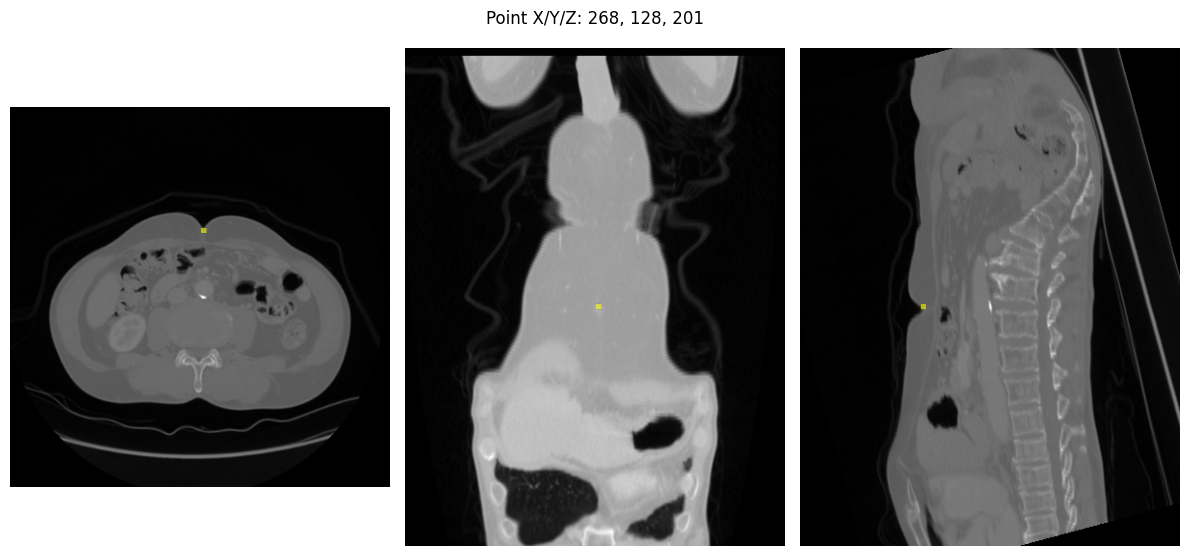

In [ ]:
# umbilicus detection [Conventional 1, Development 2]

vol = ImageReader(fpath).read()
tfm_axis = sitk_make_euler3dtransform(vol, 15, axis='x')
vol_rsl = sitk_resampler(vol, tfm_axis, new_spacing=(1,1,1))

method = 1
if method == 1:
    umbilicus_predictor = UmbilicusPredictor()
    point = umbilicus_predictor.predict(vol_rsl)
elif method ==2:
    abdomenseg = AbdomenSegmenter()
    umbilicus_detector = UmbilicusDetector()
    abdomen_image, abdomen_mask, abdomen_region, contour_list = abdomenseg.segment(vol_rsl)
    point = umbilicus_detector.detect(abdomen_image, abdomen_mask, contour_list, abdomen_region)

umbilicus_point = point.iloc[0,:3].values
figure_slices_with_umbilicus(vol_rsl, umbilicus_point)


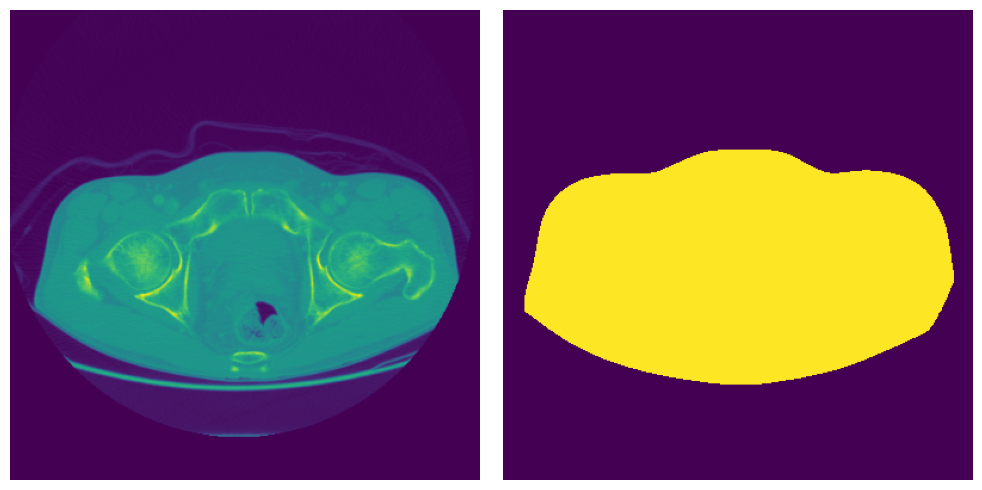

In [9]:
# Segmentation: Torso [Skin]

vol = ImageReader(fpath).read()
tfm_axis = sitk_make_euler3dtransform(vol, 15, axis='x')
vol_rsl = sitk_resampler(vol, tfm_axis, new_spacing=(1,1,1))

torsoseg = TorsoSegmenter()
torso_vol_rsl = torsoseg.segment(vol_rsl)

# check figure
import matplotlib.pyplot as plt

img_rsl = sitk_get_array(vol_rsl)
mask_rsl = sitk_get_array(torso_vol_rsl)
fig, axes = plt.subplots(1,2,figsize=(10,5))
axes[0].imshow(img_rsl[100])
axes[1].imshow(mask_rsl[100])
axes[0].axis('off'),axes[1].axis('off')
plt.tight_layout()
plt.show()


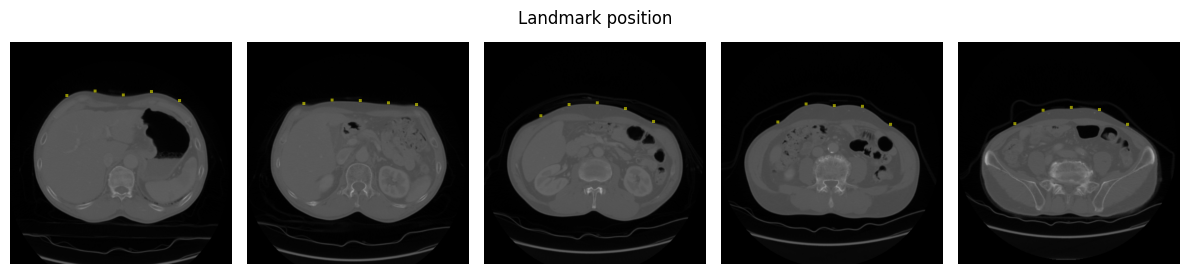

In [10]:
# Extract Landmark for Pnuemo

vol = ImageReader(fpath).read()
tfm_axis = sitk_make_euler3dtransform(vol, 15, axis='x')
vol_rsl = sitk_resampler(vol, tfm_axis, new_spacing=(1,1,1))

torsoseg = TorsoSegmenter()
torso_vol_rsl = torsoseg.segment(vol_rsl)

lm_gen = LandmarkMaskGenerator()
landmark_img, landmark_coord = lm_gen.generate_landmark_mask(
    center=umbilicus_point,
    reference_volume=torso_vol_rsl,
)
figure_slices_with_landmarks(vol_rsl, landmark_coord)


In [11]:
# Extract image patch for vision transformer

vol = ImageReader(fpath).read()
tfm_axis = sitk_make_euler3dtransform(vol, 15, axis='x')
vol_rsl = sitk_resampler(vol, tfm_axis, new_spacing=(1,1,1))

torsoseg = TorsoSegmenter()
torso_vol_rsl = torsoseg.segment(vol_rsl)

lm_gen = LandmarkMaskGenerator()
landmark_img, landmark_coord = lm_gen.generate_landmark_mask(
    center=umbilicus_point,
    reference_volume=torso_vol_rsl,
)

sample_patches_rsl = extract_patches_from_image(landmark_coord, vol_rsl, middle_size=150)
# sample_patches_rsl = extract_patches_from_image(landmark_coord, sample_vol_rsl)
print('Patch Size: ', sample_patches_rsl.shape)


Patch Size:  (250, 150, 250)


,gallbladder,liver,pancreas,spleen,stomach
value,25.128651,2061.916442,64.276146,191.228201,416.589472


,subcutaneous_fat_l3,visceral_fat_l3,muscle_l3,iliopsoas_right_l3,iliopsoas_left_l3,slice_index_l3
value,75.46124,72.808282,112.981636,5.453959,5.969154,98


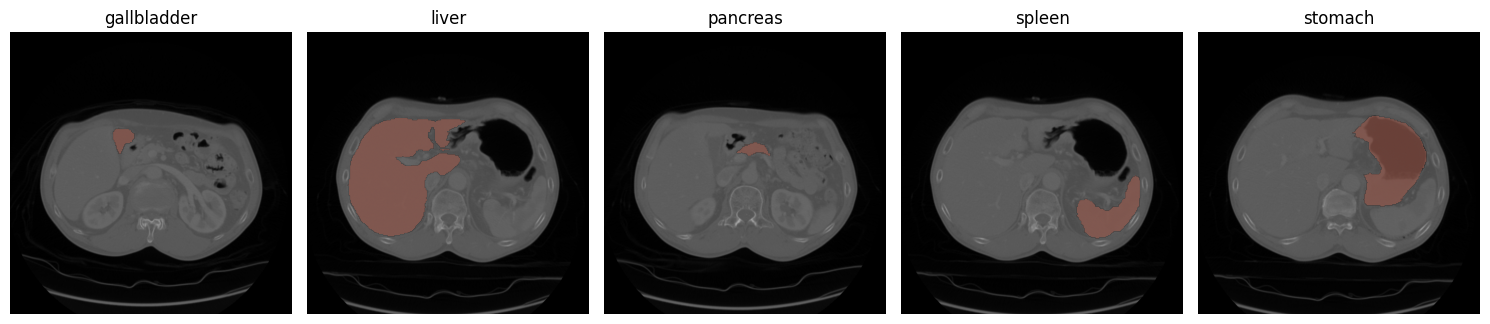

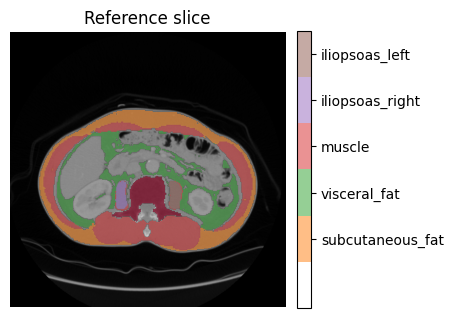

In [ ]:
# Extract volume, area, figures,,,,

vol = ImageReader(fpath).read()
tfm_axis = sitk_make_euler3dtransform(vol, 15, axis='x')
vol_rsl = sitk_resampler(vol, tfm_axis)

# mpath = 'your_fpath'
ref_vol = ImageReader(mpath / "vertebrae_L3.nii.gz").read()
ref_vol_rsl = sitk_resampler(ref_vol, tfm_axis, interpolation='nn')

# volume for selected organs
organfiles = {
    1: mpath / "gallbladder.nii.gz",
    2: mpath / "liver.nii.gz",
    3: mpath / "pancreas.nii.gz",
    4: mpath / "spleen.nii.gz",
    5: mpath / "stomach.nii.gz"
}
organ_masks, organ_vols = compute_label_volumns(organfiles, transform=tfm_axis, return_vols=True)
organ_list = organ_vols.columns.tolist()

# area for selected tissue at reference slice (L3)
tissuefiles = {
    1: mpath / "subcutaneous_fat.nii.gz",
    2: mpath / "visceral_fat.nii.gz",
    3: mpath / "muscle.nii.gz",
    4: mpath / "iliopsoas_right.nii.gz",
    5: mpath / "iliopsoas_left.nii.gz"
}

sl_idx = get_median_slice_index(ref_vol_rsl, use_transverse_process=True)
tissue_masks, tissue_areas = compute_label_areas(tissuefiles, slices_index=sl_idx, transform=tfm_axis, return_vols=True)
tissue_list = tissue_areas.columns.tolist()
tissue_areas['slice_index'] = sl_idx
tissue_areas = tissue_areas.add_suffix("_l3")

display(organ_vols, tissue_areas)

figure_overlay_label_on_slices(vol_rsl, organ_masks, labelname=organ_list, alpha=0.75, show=True)
figure_overlay_label_reference_slice(vol_rsl, tissue_masks, ref_vol_rsl, slice_idx=sl_idx, labelname=tissue_list, alpha=0.5, show=True)

